# Notebook 02 : structuration du dataset annoté, splits et pipeline de prétraitement

Le Notebook 01 a produit un inventaire complet des 27 560 images de cellules avec un audit qualité (corruption, doublons, dimensions). Ce notebook transforme cet inventaire en **dataset structuré et annoté, prêt pour l'entraînement d'un modèle** : un split stratifié train/validation/test reproductible, et un pipeline de prétraitement (redimensionnement, normalisation, augmentation) implémenté avec les classes PyTorch `Dataset`/`DataLoader`.

## 1. Chargement du manifeste propre

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

inventory = pd.read_csv(PROCESSED_DIR / "inventory.csv")
print(f"Manifeste complet : {len(inventory):,} lignes")
inventory.head(3)

Manifeste complet : 27,558 lignes


,path,label,filename,file_size_bytes,width,height,mode,md5,corrupted,duplicate
0,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_162.png,14025,142,148,RGB,6b60535df837d603b2f591d154940f1a,False,False
1,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_163.png,18152,148,208,RGB,142cdfcc8f5d2afcdd327e4886a4fbf8,False,False
2,data\raw\cell_images\Parasitized\C100P61ThinF_...,Parasitized,C100P61ThinF_IMG_20150918_144104_cell_164.png,12825,139,151,RGB,2db29c733097f1736cdba4055e1549d6,False,False


In [2]:
clean = inventory.loc[(~inventory["corrupted"]) & (~inventory["duplicate"])].reset_index(drop=True)

display(
    Markdown(
        f"**Exclues :** `{inventory['corrupted'].sum()}` lignes corrompues + `{inventory['duplicate'].sum()}` lignes en doublon.  \n"
        f"**Images utilisables :** `{len(clean):,}`"
    )
)
clean["label"].value_counts()

**Exclues :** `0` lignes corrompues + `0` lignes en doublon.  
**Images utilisables :** `27,558`

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

## 2. Split stratifié train / validation / test

Un split 70/15/15 est construit avec une seed fixe (42) et stratifié sur `label`, pour que chaque sous-ensemble conserve le même équilibre de classes que le dataset complet. Le split se fait en deux étapes avec `sklearn.model_selection.train_test_split` : on sépare d'abord 70% pour l'entraînement, puis on répartit les 30% restants à parts égales entre validation et test.

**Point d'attention :** le split se fait au niveau de l'image, pas au niveau du patient ou de la lame. Les noms de fichiers encodent un identifiant de lame (ex. `C116P77...`), et plusieurs cellules sont recadrées à partir du même champ de microscopie, donc un protocole plus strict regrouperait par lame pour éliminer complètement tout risque de fuite entre les splits. C'est signalé ici comme une simplification connue et repris comme limite dans le Notebook 04. Pour un benchmark de cette envergure, la priorité est un split stratifié par label propre et reproductible.

In [3]:
train_df, temp_df = train_test_split(
    clean, test_size=0.30, stratify=clean["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(df):6,} images ({len(df) / len(clean):.1%})")

split_summary = pd.concat(
    {
        "train": train_df["label"].value_counts(),
        "val": val_df["label"].value_counts(),
        "test": test_df["label"].value_counts(),
    },
    axis=1,
)
split_summary["train_%"] = (split_summary["train"] / split_summary["train"].sum() * 100).round(2)
split_summary["val_%"] = (split_summary["val"] / split_summary["val"].sum() * 100).round(2)
split_summary["test_%"] = (split_summary["test"] / split_summary["test"].sum() * 100).round(2)
display(split_summary)

train: 19,290 images (70.0%)
val  :  4,134 images (15.0%)
test :  4,134 images (15.0%)


,train,val,test,train_%,val_%,test_%
label,,,,,,
Uninfected,9645,2067,2067,50.0,50.0,50.0
Parasitized,9645,2067,2067,50.0,50.0,50.0


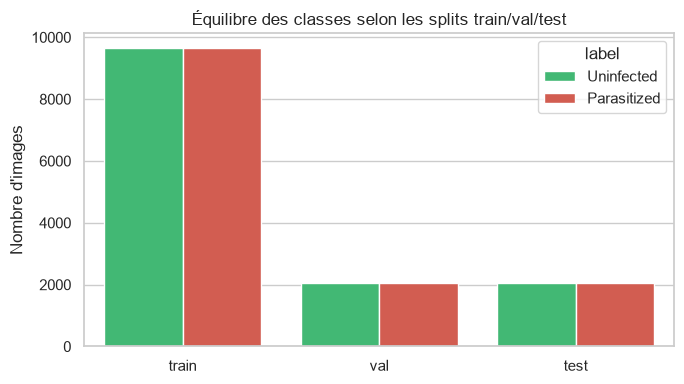

In [4]:
plt.figure(figsize=(7, 4))
plot_df = split_summary[["train", "val", "test"]].reset_index().melt(
    id_vars="label", var_name="split", value_name="count"
)
sns.barplot(data=plot_df, x="split", y="count", hue="label", palette={"Parasitized": "#e74c3c", "Uninfected": "#2ecc71"})
plt.title("Équilibre des classes selon les splits train/val/test")
plt.ylabel("Nombre d'images")
plt.xlabel("")
plt.tight_layout()
plt.show()

Le split préserve l'équilibre ~50/50 des classes dans les trois sous-ensembles, comme attendu avec la stratification. Un équilibre de classes (quasi) identique entre les splits signifie que l'accuracy ne sera pas trompeuse à elle seule dans les Notebooks 03/04, même si les métriques cliniquement pertinentes (sensibilité, spécificité, VPP, VPN) restent suivies séparément dans le Notebook 04, la prévalence réelle étant loin d'être 50/50.

## 3. Pipeline de prétraitement

**Taille cible du redimensionnement : 64x64 px.** Les images sources sont des recadrages de cellule unique en basse résolution (taille médiane autour de 130x130 px d'après le Notebook 01), sans détail sous-cellulaire fin en dehors du motif de coloration, et l'entraînement tourne uniquement sur CPU (pas de CUDA sur cette machine). 64x64 permet de garder chaque passe avant/arrière assez rapide pour entraîner plusieurs modèles en quelques minutes, tout en conservant assez de résolution pour voir clairement la coloration du parasite, vérifié visuellement ci-dessous.

**Normalisation :** les moyennes/écarts-types ImageNet (`[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`) sont utilisés à la fois pour le CNN from scratch et pour le modèle de transfer learning du Notebook 03, plutôt que des statistiques propres au dataset. Cela garde les deux pipelines directement comparables et est de toute façon requis pour la branche de transfer learning, puisque les filtres pré-entraînés de `resnet18` attendent une entrée normalisée façon ImageNet.

**Augmentation (split d'entraînement uniquement) :** flip horizontal aléatoire, flip vertical aléatoire, et une petite rotation aléatoire (±15°). L'orientation des cellules au microscope est arbitraire, donc ces flips/rotations préservent le label et rendent simplement le jeu d'entraînement plus représentatif des orientations de lames non vues. Aucune augmentation n'est appliquée sur validation/test, puisque ces splits doivent refléter les données telles qu'elles arrivent réellement.

In [5]:
IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. `Dataset` et `DataLoader` PyTorch

In [6]:
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


class MalariaCellDataset(Dataset):
    '''Images de cellules uniques issues de frottis sanguin, chargées à partir des manifestes CSV.'''

    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = LABEL_TO_IDX[row["label"]]
        return img, label


train_dataset = MalariaCellDataset(train_df.assign(label=train_df["label"]), PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)
test_dataset = MalariaCellDataset(test_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
print(f"train_dataset: {len(train_dataset):,} | val_dataset: {len(val_dataset):,} | test_dataset: {len(test_dataset):,}")
print(f"Forme du batch : {batch_x.shape}, dtype {batch_x.dtype} ; forme des labels {batch_y.shape}")

train_dataset: 19,290 | val_dataset: 4,134 | test_dataset: 4,134
Forme du batch : torch.Size([32, 3, 64, 64]), dtype torch.float32 ; forme des labels torch.Size([32])


### Vérification visuelle : un batch d'images d'entraînement augmentées

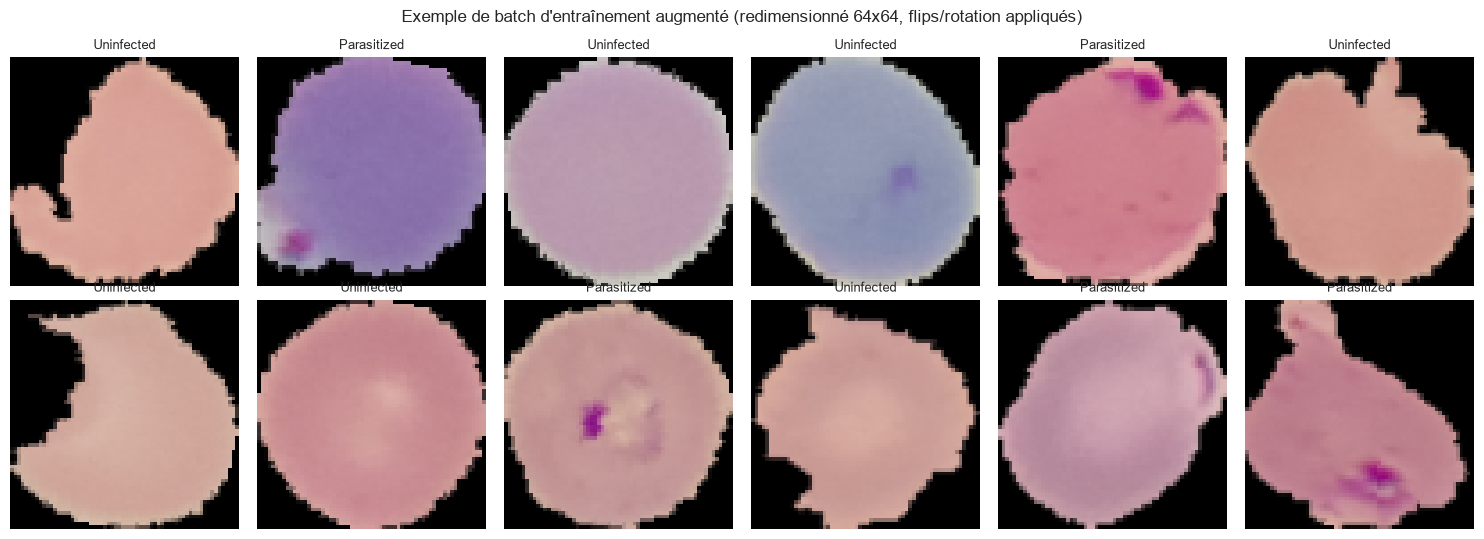

In [7]:
def denormalize(tensor_img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor_img * std + mean).clamp(0, 1)


fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for i in range(12):
    img = denormalize(batch_x[i]).permute(1, 2, 0).numpy()
    ax = axes[i // 6, i % 6]
    ax.imshow(img)
    ax.set_title(IDX_TO_LABEL[batch_y[i].item()], fontsize=9)
    ax.axis("off")
fig.suptitle("Exemple de batch d'entraînement augmenté (redimensionné 64x64, flips/rotation appliqués)", fontsize=12)
plt.tight_layout()
plt.show()

Même à une résolution de 64x64, le motif de coloration qui distingue les cellules parasitées des cellules saines reste visible, ce qui confirme le compromis résolution/vitesse fait plus haut. Les recadrages augmentés (flip/rotation) ressemblent toujours à des champs de microscopie plausibles, ce qui confirme que les transformations préservent bien le label.

## 5. Export des manifestes annotés

In [8]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    out_path = PROCESSED_DIR / f"{name}.csv"
    df[["path", "label"]].to_csv(out_path, index=False)
    print(f"{out_path.name} sauvegardé : {len(df):,} lignes")

train.csv sauvegardé : 19,290 lignes
val.csv sauvegardé : 4,134 lignes
test.csv sauvegardé : 4,134 lignes


## Résumé et passage de relais au Notebook 03

* Split stratifié 70/15/15, seed 42, sauvegardé dans `data/processed/{train,val,test}.csv` ; tailles indiquées dans la Section 2 ci-dessus.
* Prétraitement : redimensionnement en 64x64, normalisation ImageNet, augmentation sur l'entraînement uniquement (flip horizontal/vertical, plus ou moins 15 degrés de rotation).
* Classes `MalariaCellDataset` / `DataLoader` définies et vérifiées sur un batch réel.
* Simplification connue : le split est fait au niveau image et non au niveau lame, ce qui est reconnu comme une limite, pas caché.